In [269]:
# import os
# import cmdstanpy

# cmdstan_base_dir = "/home/onyxia/work/cmdstan"

# # 1. Détection et compilation conditionnelle du backend C++
# if not os.path.exists(cmdstan_base_dir) or not any(d.startswith("cmdstan-") for d in os.listdir(cmdstan_base_dir)):
#     print(f"Absence du backend C++. Téléchargement et compilation initiés dans {cmdstan_base_dir}...")
#     # La compilation nécessite g++ et make (déjà présents sur l'image VSCode Python d'Onyxia)
#     cmdstanpy.install_cmdstan(dir=cmdstan_base_dir)

# # 2. Assignation stricte du chemin 
# try:
#     installed_versions = [d for d in os.listdir(cmdstan_base_dir) if d.startswith("cmdstan-")]
#     # Trie pour garantir la sélection de la version la plus récente si plusieurs existent
#     installed_versions.sort(reverse=True) 
    
#     cmdstan_path = os.path.join(cmdstan_base_dir, installed_versions[0])
#     cmdstanpy.set_cmdstan_path(cmdstan_path)
#     print(f"Liaison matérielle CmdStan établie sur : {cmdstanpy.cmdstan_path()}")
# except Exception as e:
#     raise RuntimeError(f"Échec critique lors de la résolution des binaires CmdStan : {e}")

## RHO PAR DYADE, MULTITHREADING, hurdle logit ~alpha + gamma + X_h*beta_h + beta_lag_m49[cluster_h]*is_mig_lag

In [270]:
import warnings

import os
import cmdstanpy
from cmdstanpy import CmdStanModel

import pandas as pd
import numpy as np

import xgboost as xgb
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve , roc_auc_score, accuracy_score
from itertools import product

#from sklearn.ensemble import RandomForestClassifier
from scipy.special import logit as scipy_logit

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = "../data/panel_june_filled.csv"
#STAN_FILE  = "../STAN/HMC_hurdle_regression_vectorized.stan"
OUTPUT_DIR = "./stan_outputs_tmux"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## D'ici la réunion 8 Juillet 
* réfléchir à un plan/draft; lire du JRSS A 
* dataset: compléter ou réfléchir à exclure proprement les états problématiques. covariables concernées: LA LL urban ; PSE DROM-TOM etc.
* relancer simulation avec Hurdle logit et rf / xgb, et quantifier rho dyadique/cluster 
* résoudre faiblesse hyper-régression
* trancher méthode W_FP
* tester BART sur subsamples et trancher ; on peut le mentionner en Discussion. 


### tester gdpcap_lag1 pour l'horizon 1; réfléchir à la dimension temporelle (prédiction 2011-2014? =/= 2015?)



Var(flow_ij) = E[Var(flow | p_ij)] + Var(E[flow | p_ij])
                    ^ variance volume          ^ variance hurdle
ce deuxième terme est nul quand p_ij est donnée exogène du XGBoost

In [271]:
# Sampling parameters
N_CHAINS        = 4
PARALLEL_CHAINS = 4
ITER_WARMUP     = 500
ITER_SAMPLING   = 400
THIN            = 1
MAX_TREEDEPTH   = 12
ADAPT_DELTA     = 0.95
N_DRAWS         = ITER_SAMPLING // THIN

# Contrôle matériel : vectorized ou multithreading
USE_MULTITHREADING = False  # True (reduce_sum) / False (Vectorisation standard)


# SUBSET DE PAYS (modifier RUN_SIZE uniquement)

RUN_SIZE = 1
# _LABELS  = {1: '50 pays', 2: '80 pays', 3: '110 pays', 4: '140 pays', 5: '190 pays (complet)'}


In [272]:
df_main = pd.read_csv(DATA_PATH)
df = df_main[df_main['orig'] != df_main['dest']].copy()

PAYS_EXCLURE = {
    'SSD', 'CUW', #'MNE', 'TLS', 
    'GUM', 'MYT', 'VIR', 'CLI', # on va essayer d'intégrer ceux-là manuellement (manque le PIB)
}
df = df[
    ~df['orig'].isin(PAYS_EXCLURE) &
    ~df['dest'].isin(PAYS_EXCLURE)
].copy()

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"{df['orig'].nunique()} pays après exclusions")

190 pays après exclusions


In [273]:
# 1. Base 50 : Échantillon fondamental. Diversité géographique maximale et intégration des plus grands pôles.
PAYS_SUBSET_50 = {
    # Amérique du Nord & Sud
    'USA', 'CAN', 'MEX', 'BRA', 'ARG', 'COL', 'CHL', 'PER', 'VEN',
    # Europe
    'FRA', 'DEU', 'GBR', 'ITA', 'ESP', 'POL', 'RUS', 'UKR', 'SWE', 'NLD', 'ROU',
    # Asie & Moyen-Orient
    'CHN', 'IND', 'JPN', 'KOR', 'IDN', 'PAK', 'BGD', 'PHL', 'VNM', 'TUR', 'IRN', 'SAU', 'THA', 'MYS', 'KAZ',
    # Afrique
    'NGA', 'ETH', 'EGY', 'COD', 'ZAF', 'TZA', 'KEN', 'DZA', 'MAR', 'GHA', 'CIV', 'AGO', 'SEN',
    # Océanie
    'AUS', 'NZL'
}

# 2. Base 80 : +30 pays. Densification des régions d'Europe continentale, Asie centrale/sud, et Afrique subsaharienne.
PAYS_SUBSET_80 = PAYS_SUBSET_50 | {
    'NOR', 'FIN', 'DNK', 'CHE', 'AUT', 'BEL', 'GRC', 'CZE',
    'BOL', 'ECU', 'URY', 'GTM', 'CUB', 'DOM',
    'IRQ', 'ISR', 'ARE', 'UZB', 'MMR', 'LKA', 'NPL', 'AFG',
    'CMR', 'MLI', 'BFA', 'MOZ', 'ZMB', 'RWA', 'TUN', 'SDN'
}

# 3. Base 110 : +30 pays. Ajout de l'Europe de l'Est, Amérique centrale, péninsule arabique et Afrique francophone/australe.
PAYS_SUBSET_110 = PAYS_SUBSET_80 | {
    'HUN', 'PRT', 'IRL', 'BGR', 'SRB', 'HRV', 'BLR', 'SVK',
    'HND', 'SLV', 'NIC', 'CRI', 'PAN', 'PRY',
    'JOR', 'LBN', 'KWT', 'OMN', 'YEM', 'KHM', 'SGP',
    'TCD', 'NER', 'GIN', 'BDI', 'SOM', 'MWI', 'COG', 'GAB', 'NAM'
}

# 4. Base 140 : +30 pays. Ajout des pays baltes, Balkans, Caraïbes, Asie mineure et Océanie isolée.
PAYS_SUBSET_140 = PAYS_SUBSET_110 | {
    'LTU', 'LVA', 'EST', 'SVN', 'MKD', 'BIH', 'ALB', 'MDA',
    'HTI', 'JAM', 'TTO', 'BHS', 'GUY', 'SUR',
    'QAT', 'BHR', 'SYR', 'TJK', 'KGZ', 'LAO', 'MNG',
    'LBY', 'MRT', 'TGO', 'BEN', 'LBR', 'SLE', 'CAF',
    'PNG', 'FJI'
}


_SUBSETS = {1: PAYS_SUBSET_50, 2: PAYS_SUBSET_80, 3: PAYS_SUBSET_110, 4: PAYS_SUBSET_140, 5: None}
_LABELS  = {1: '50 pays', 2: '80 pays', 3: '110 pays', 4: '140 pays', 5: '190 pays (complet)'}


if RUN_SIZE < 5:
    pays_subset = _SUBSETS[RUN_SIZE]
    # Application des masques stricts sur orig et dest
    df = df[df['orig'].isin(pays_subset) & df['dest'].isin(pays_subset)].copy()
N_pays = df['orig'].nunique()
print(f"Run : {df['orig'].nunique()} pays dans le panel")

Run : 50 pays dans le panel


In [274]:
# clustering M49

ISO3_TO_M49_SUBREGION = {
    'DNK': 11, 'EST': 11, 'FIN': 11, 'ISL': 11, 'IRL': 11, 'LVA': 11, 'LTU': 11, 'NOR': 11, 'SWE': 11, 'GBR': 11,
    'ALB': 12, 'AND': 12, 'BIH': 12, 'HRV': 12, 'GRC': 12, 'ITA': 12, 'MLT': 12, 'MNE': 12, 'MKD': 12, 'PRT': 12, 'SRB': 12, 'SVN': 12, 'ESP': 12,
    'AUT': 13, 'BEL': 13, 'FRA': 13, 'DEU': 13, 'LIE': 13, 'LUX': 13, 'MCO': 13, 'NLD': 13, 'CHE': 13,
    'BLR': 14, 'BGR': 14, 'CZE': 14, 'HUN': 14, 'POL': 14, 'MDA': 14, 'ROU': 14, 'RUS': 14, 'SVK': 14, 'UKR': 14,
    'DZA': 15, 'EGY': 15, 'LBY': 15, 'MAR': 15, 'SDN': 15, 'TUN': 15, 'ESH': 15,
    'BEN': 16, 'BFA': 16, 'CPV': 16, 'CIV': 16, 'GMB': 16, 'GHA': 16, 'GIN': 16, 'GNB': 16, 'LBR': 16, 'MLI': 16, 'MRT': 16, 'NER': 16, 'NGA': 16, 'SEN': 16, 'SLE': 16, 'TGO': 16,
    'BDI': 17, 'COM': 17, 'DJI': 17, 'ERI': 17, 'ETH': 17, 'KEN': 17, 'MDG': 17, 'MWI': 17, 'MUS': 17, 'MOZ': 17, 'REU': 17, 'RWA': 17, 'SYC': 17, 'SOM': 17, 'SSD': 17, 'TZA': 17, 'UGA': 17, 'ZMB': 17, 'ZWE': 17,
    'AGO': 18, 'CMR': 18, 'CAF': 18, 'TCD': 18, 'COD': 18, 'COG': 18, 'GNQ': 18, 'GAB': 18, 'STP': 18,
    'BWA': 19, 'LSO': 19, 'NAM': 19, 'ZAF': 19, 'SWZ': 19,
    'CAN': 21, 'MEX': 21, 'USA': 21,
    'BLZ': 22, 'CRI': 22, 'SLV': 22, 'GTM': 22, 'HND': 22, 'NIC': 22, 'PAN': 22,
    'ATG': 23, 'BHS': 23, 'BRB': 23, 'CUB': 23, 'DMA': 23, 'DOM': 23, 'GLP': 23, 'GRD': 23, 'HTI': 23, 'JAM': 23, 'KNA': 23, 'LCA': 23, 'MTQ': 23, 'VCT': 23, 'TTO': 23, 'ABW': 23, 'PRI': 23,
    'ARG': 24, 'BOL': 24, 'BRA': 24, 'CHL': 24, 'COL': 24, 'ECU': 24, 'GUF': 24, 'GUY': 24, 'PRY': 24, 'PER': 24, 'SUR': 24, 'URY': 24, 'VEN': 24,
    'CHN': 30, 'HKG': 30, 'JPN': 30, 'KOR': 30, 'MAC': 30, 'MNG': 30, 'PRK': 30,
    'AFG': 34, 'BGD': 34, 'BTN': 34, 'IND': 34, 'IRN': 34, 'MDV': 34, 'NPL': 34, 'PAK': 34, 'LKA': 34,
    'BRN': 35, 'KHM': 35, 'IDN': 35, 'LAO': 35, 'MYS': 35, 'MMR': 35, 'PHL': 35, 'SGP': 35, 'THA': 35, 'TLS': 35, 'VNM': 35,
    'ARM': 145, 'AZE': 145, 'BHR': 145, 'CYP': 145, 'GEO': 145, 'IRQ': 145, 'ISR': 145, 'JOR': 145, 'KWT': 145, 'LBN': 145, 'OMN': 145, 'QAT': 145, 'SAU': 145, 'PSE': 145, 'SYR': 145, 'TUR': 145, 'ARE': 145, 'YEM': 145,
    'KAZ': 143, 'KGZ': 143, 'TJK': 143, 'TKM': 143, 'UZB': 143,
    'AUS': 53, 'FJI': 53, 'NZL': 53, 'PNG': 53, 'SLB': 53, 'VUT': 53, 'WSM': 53, 'TON': 53, 'KIR': 53, 'FSM': 53, 'GUM': 53, 'NCL': 53, 'PYF': 53,
}

SUBREGION_LABELS = {
    11: 'Europe du Nord', 12: 'Europe du Sud', 13: "Europe de l'Ouest", 14: "Europe de l'Est",
    15: 'Afrique du Nord', 16: "Afrique de l'Ouest", 17: "Afrique de l'Est", 18: 'Afrique Centrale', 19: 'Afrique Australe',
    21: 'Amerique du Nord', 22: 'Amerique Centrale', 23: 'Caraibes', 24: 'Amerique du Sud',
    30: "Asie de l'Est", 34: 'Asie du Sud', 35: 'Asie du Sud-Est',
    143: 'Asie Centrale', 145: "Asie de l'Ouest", 53: 'Oceanie', 99: 'Non classifie'
}

df['m49_brut'] = df['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
_UNIQUE_M49_PRESENT = sorted(df['m49_brut'].unique())
_M49_TO_STAN = {m49: i + 1 for i, m49 in enumerate(_UNIQUE_M49_PRESENT)}
stan_to_m49 = {v: k for k, v in _M49_TO_STAN.items()}
df['continent_orig'] = df['m49_brut'].map(_M49_TO_STAN)
K_clusters = len(_M49_TO_STAN)
print(f"{K_clusters} clusters M49")

17 clusters M49


In [275]:
# df['is_migration'] = (df['flow'] > 0).astype(int)
# df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)
# df['log_flow_lag'] = df.groupby(['orig', 'dest'])['log_flow'].shift(1)
# df['is_mig_lag']   = df.groupby(['orig', 'dest'])['is_migration'].shift(1)
# df['log_D_ij']     = np.log(df['D_ij'].replace(0, np.nan))
# df['log_D_ij_sq']  = df['log_D_ij'] ** 2
# df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']


df['dyad'] = df['orig'] + "_" + df['dest']

# df['instability_o'] = df['v2x_clphy_o_lag1'] - df['v2x_polyarchy_o_lag1']
# df['instability_d'] = df['v2x_clphy_d_lag1'] - df['v2x_polyarchy_d_lag1']

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

# inutile déjà calculé par build_dataset, à supprimer: 
# for col_base, group_key in [
#     ('intensity_level_o_lag1', 'orig'),
#     ('type_of_conflict_o_lag1', 'orig'),
#     ('intensity_level_d_lag1', 'dest'),
#     ('type_of_conflict_d_lag1', 'dest'),
# ]:
#     new_col = f'{col_base}_persist'
#     df[new_col] = df.groupby([group_key, 'dest' if group_key == 'orig' else 'orig'])[col_base] \
#         .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())

df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 'urban_it', 'urban_jt', 'LA_i', 'LA_j']
for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan)) # créer les variables log

In [276]:

# HURDLE_VARS RF avec colinéarité 
HURDLE_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    'v2x_polyarchy_o_lag1',# 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1'#, 'v2x_clphy_d_lag1', 'intensity_level_d_lag1'#, 'is_mig_lag'
]

X_VOL_COLS = [
    'log_D_ij', 'log_D_ij_sq', 'LB_ij', 'OL_ij', 'COL_ij', #'t_2000', 't_2000_sq',
    'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1'#, 'type_of_conflict_d_lag1',
]

K_grav = len(X_VOL_COLS)
K_h = len(HURDLE_VARS) + 1 # +1 pour logit_xgb

df_train = df[df['year'] <= 2010].copy()
df_test = df[df['year'] == 2015].copy()
df_test_full = df_test.copy()
df_test_full['dyad'] = df_test_full['orig'] + "_" + df_test_full['dest']
df = df_train

In [277]:
HURDLE_REQUIRED = HURDLE_VARS + [ 'is_migration', 'dyad', 'continent_orig',
                                 'is_mig_lag'
                                 ] 
# covariables + is_mig_lag ne devant pas être standardisée et occupant une place théorique particulière (hystérésis) 
# + variables structurelles  dont Stan a besoin pour l'entraînement et la vraisemblance 
# (dyad pour les effets fixes alpha_i et gamma_j, continent_orig pour les effets de cluster M49)
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

df['has_history'] = (
    df.groupby(['orig', 'dest'])['flow']
    .transform(lambda x: (x.shift(1) > 0).expanding().max()) > 0
).astype(int) # voir notes .pages, history correspond à max(Y_0, Y_1, ..., Y_t-1)>0

#VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'log_flow_lag', 'dyad', 'continent_orig']
VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'is_mig_lag', 'has_history', 'dyad', 'continent_orig']
#df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy()
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

# états markovien, pour handle amnésie markovienne dans le modèle de volume
is_continu = (df_volume['is_mig_lag'] == 1)
is_virgin  = (df_volume['is_mig_lag'] == 0) & (df_volume['has_history'] == 0) 

# EXCLUSION PURE des trous pour la ZTNB et le ARX(1)
df_volume = df_volume[is_continu | is_virgin].copy().reset_index(drop=True)

df_volume['is_emergent_v'] = (1 - df_volume['is_mig_lag']).astype(int)
df_volume['log_flow_lag_clean'] = df_volume['log_flow_lag'].fillna(0.0) # Bruit neutralisé par la bifurcation Stan

N_h, N_v = len(df_hurdle), len(df_volume)
print(f"Hurdle : {N_h:,} obs | Volume : {N_v:,} obs sans trous")


Hurdle : 12,250 obs | Volume : 10,014 obs sans trous


In [278]:
out_degree = df_hurdle.groupby(['orig', 'year'])['is_mig_lag'].sum().reset_index(name='out_degree_o')
in_degree  = df_hurdle.groupby(['dest', 'year'])['is_mig_lag'].sum().reset_index(name='in_degree_d')
df_hurdle  = df_hurdle.merge(out_degree, on=['orig', 'year'], how='left')
df_hurdle  = df_hurdle.merge(in_degree,  on=['dest', 'year'], how='left')
df_hurdle['transitivity_proxy'] = (
    df_hurdle['out_degree_o'].fillna(0) * df_hurdle['in_degree_d'].fillna(0)
)

out_deg_agg = df_hurdle.groupby('orig')['out_degree_o'].mean().reset_index()
in_deg_agg  = df_hurdle.groupby('dest')['in_degree_d'].mean().reset_index()

df_test = df_test.merge(out_deg_agg, on='orig', how='left')
df_test = df_test.merge(in_deg_agg,  on='dest', how='left')
df_test['transitivity_proxy'] = (df_test['out_degree_o'].fillna(0) * df_test['in_degree_d'].fillna(0))

# REVOIR CONSTRUCTION .MEAN DE TRANS_PROXY


#  A2_{t-1} : nb de chemins i->k->j actifs à t-1 (signal stepping-stone) 
# A[i,j] = is_mig_lag(i,j,t) = 1{Y_{ij,t-1} > 0}  ->  (A@A)[i,j] = #{k : i->k et k->j actifs}
pays_all = sorted(set(df_hurdle['orig']) | set(df_hurdle['dest'])
                  | set(df_test['orig']) | set(df_test['dest']))
pid = {p: i for i, p in enumerate(pays_all)}
Np = len(pays_all)

def a2_feature(frame):
    out = np.zeros(len(frame))
    for yr, sub in frame.groupby('year'):
        A = np.zeros((Np, Np), dtype=np.float32)
        act = sub[sub['is_mig_lag'] == 1]
        A[act['orig'].map(pid).values, act['dest'].map(pid).values] = 1.0
        A2 = A @ A                                   # ~192^3 flops : instantané
        oi = sub['orig'].map(pid).values
        dj = sub['dest'].map(pid).values
        out[frame.index.get_indexer(sub.index)] = A2[oi, dj]
    return out

df_hurdle['A2_log'] = np.log1p(a2_feature(df_hurdle))
df_test['A2_log']   = np.log1p(a2_feature(df_test))

if 'A2_log' not in HURDLE_VARS:
    HURDLE_VARS = HURDLE_VARS + ['A2_log']
    


# La démonstration clé : A^2 est non-nul là où toutes les variables d'inertie sont muettes
mask_fn_zone = (df_test['is_mig_lag'] == 0) & (df_test.get('log_stock_lag', 0) == 0)
print(f"Zone FN (lag=0, stock=0) : {mask_fn_zone.sum():,} dyades, "
      f"A2>0 pour {(df_test.loc[mask_fn_zone,'A2_log']>0).mean()*100:.1f}% d'entre elles")






Zone FN (lag=0, stock=0) : 398 dyades, A2>0 pour 100.0% d'entre elles


In [279]:
from sklearn.ensemble import RandomForestClassifier

RF_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    #'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    #'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
    'log_gdpcap_o_lag5', 'log_gdpcap_d_lag5', 'log_gdpcap_diff',
    'log_P_it', 'log_P_jt',
    'is_mig_lag',
    'PSR_i', 'PSR_j',
    'IMR_it', 'IMR_jt',
    'urban_it', 'urban_jt',
    'LL_i', 'LL_j',
    'LA_i', 'LA_j',
    'LB_ij', 'logD_times_LB',
    'type_of_conflict_o_lag1', 'type_of_conflict_d_lag1',
    'transitivity_proxy',
    'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5', 'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
    'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5', 'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
    'log_stock_lag',
    'any_conflict_o_window', 'max_conflict_o_window', 'any_intense_o_window', 'any_intl_o_window',
    'any_conflict_d_window', 'max_conflict_d_window', 'any_intense_d_window', 'any_intl_d_window',
    'new_conflict_o', 'new_conflict_d', 'persistent_conflict_o', 'persistent_conflict_d', 'A2_log'
]

eps = 1e-6

RF_VARS_PRESENT = [c for c in RF_VARS if c in df_hurdle.columns]
print(f"Variables RF : {len(RF_VARS_PRESENT)}")

X_rf_train = df_hurdle[RF_VARS_PRESENT].fillna(0).values
y_rf_train = df_hurdle['is_migration'].values

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_rf_train, y_rf_train)

auc_train = roc_auc_score(y_rf_train, rf_model.predict_proba(X_rf_train)[:, 1])
print(f"RF AUC train : {auc_train:.4f}")

# Injection du logit RF comme covariable de la régression Hurdle (modèle n°1)
proba_rf_train = rf_model.predict_proba(X_rf_train)[:, 1].clip(eps, 1 - eps)
df_hurdle['logit_rf'] = scipy_logit(proba_rf_train)

RF_VARS_TEST = [c for c in RF_VARS_PRESENT if c in df_test.columns]
proba_rf_test = rf_model.predict_proba(df_test[RF_VARS_TEST].fillna(0).values)[:, 1].clip(eps, 1 - eps)
df_test['proba_rf'] = proba_rf_test
df_test['logit_rf'] = scipy_logit(proba_rf_test)

HURDLE_VARS = HURDLE_VARS + ['logit_rf']
K_h = len(HURDLE_VARS)
print(f"K_h : {K_h}")


print(pd.Series(rf_model.feature_importances_, index=RF_VARS_PRESENT).sort_values(ascending=False).head(10).round(4))


Variables RF : 47
RF AUC train : 0.9943
K_h : 8
is_mig_lag              0.2497
transitivity_proxy      0.1306
A2_log                  0.0995
log_stock_lag           0.0492
PSR_j                   0.0488
PSR_i                   0.0344
log_gdpcap_d_lag5       0.0333
log_gdpcap_o_lag5       0.0330
v2x_polyarchy_d_lag5    0.0329
log_D_ij_sq             0.0319
dtype: float64


In [280]:
# /!!!!!\

df_test['log_flow_lag_clean'] = (
    df_test['log_flow_lag'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
)

# /!!!!!\




BINARY_COLS_VOL = ['LB_ij', 'OL_ij', 'COL_ij']
BINARY_COLS_HUR = ['LB_ij', 'COL_ij', 'OL_ij'] # standardisation de logit_rf / xgb

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

dyades_h = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i + 1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (
    df_hurdle.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
    .values.astype(int)
)

dyades_v = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i + 1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (
    df_volume.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
    .values.astype(int)
)

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)

In [281]:
df_test['dyad'] = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']   = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v'] = df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)
df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)
df_test = df_test.dropna(subset=['log_gdpcap_d_lag'] + HURDLE_VARS + X_VOL_COLS).copy().reset_index(drop=True)
df_test['dyad_id_test'] = df_test['dyad_id_test'].astype(int)

df_test['m49_brut'] = df_test['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
df_test['continent_orig_fill'] = df_test['m49_brut'].map(_M49_TO_STAN).fillna(K_clusters).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values  # toujours nécessaire pour rho_m49[k] et phi_disp_cluster[k] dans Stan


X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR, fit_stats=stats_h)


tous_les_pays = sorted(list(set(df['orig'].unique()).union(set(df['dest'].unique()))))
pays_to_id    = {pays: i + 1 for i, pays in enumerate(tous_les_pays)}
N_pays_total  = len(tous_les_pays)

df_volume['orig_id_v'] = df_volume['orig'].map(pays_to_id)
df_volume['dest_id_v'] = df_volume['dest'].map(pays_to_id)
df_hurdle['orig_id_h'] = df_hurdle['orig'].map(pays_to_id)
df_hurdle['dest_id_h'] = df_hurdle['dest'].map(pays_to_id)
df_test['orig_id_test_v'] = df_test['orig'].map(pays_to_id)
df_test['dest_id_test_v'] = df_test['dest'].map(pays_to_id)

print(f"Test OOS : {len(df_test):,} obs")

Test OOS : 2,450 obs


In [282]:
K_Z = 1
Z_mat = np.zeros((N_pays_total, K_Z))

# Dernière période d'entraînement disponible par pays
df_last = df_train[df_train['year'] == df_train['year'].max()]  # year == 2010
#df_last = df_test[df_test['year'] == 2015]  

for pays, pays_id in pays_to_id.items():
    idx = pays_id - 1

    sub_orig = df_last[df_last['orig'] == pays]
    sub_dest = df_last[df_last['dest'] == pays]

    if not sub_orig.empty:
        log_mass = sub_orig['log_P_it'].iloc[0] + sub_orig['log_gdpcap_o_lag1'].iloc[0]
    elif not sub_dest.empty:
        log_mass = sub_dest['log_P_jt'].iloc[0] + sub_dest['log_gdpcap_d_lag1'].iloc[0]
    else:
        log_mass = np.nan

    Z_mat[idx, 0] = log_mass

col_median = np.nanmedian(Z_mat[:, 0])
for idx, pays in enumerate(pays_to_id.keys()):
    if np.isnan(Z_mat[idx, 0]):
        m49 = ISO3_TO_M49_SUBREGION.get(pays, 99)
        pays_meme_region = [p for p, m in ISO3_TO_M49_SUBREGION.items()
                            if m == m49 and p in pays_to_id]
        vals_region = [Z_mat[pays_to_id[p] - 1, 0]
                       for p in pays_meme_region
                       if not np.isnan(Z_mat[pays_to_id[p] - 1, 0])]
        Z_mat[idx, 0] = np.median(vals_region) if vals_region else col_median
Z_mat[:, 0] = (Z_mat[:, 0] - np.mean(Z_mat[:, 0])) / np.std(Z_mat[:, 0])

Z_em = Z_mat
Z_at = Z_mat

print(f"Z_mat — NaN résiduels : {np.isnan(Z_mat).sum()} | min : {Z_mat.min():.2f} | max : {Z_mat.max():.2f}")

Z_mat — NaN résiduels : 0 | min : -1.94 | max : 2.44


# penser à prendre le PIB courant de 2010 une fois dispo dans le dataset

In [283]:
df_hurdle = df_hurdle.replace([np.inf, -np.inf], np.nan).dropna(subset=HURDLE_REQUIRED)
df_volume = df_volume.replace([np.inf, -np.inf], np.nan).dropna(subset=VOLUME_REQUIRED)
N_h, N_v = len(df_hurdle), len(df_volume)
assert np.isinf(df_volume[X_VOL_COLS].values).sum() == 0

stan_data = {
    # Dimensions globales 
    'N_pays'     : N_pays_total,
    'K_clusters' : int(K_clusters),

    # Hyper-régression 
    'K_Z'  : int(K_Z),
    'Z_em' : Z_em.tolist(),
    'Z_at' : Z_at.tolist(),

    # URDLE (train)
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'orig_id_h'  : df_hurdle['orig_id_h'].astype(int).tolist(),
    'dest_id_h'  : df_hurdle['dest_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    #  VOLUME (train) 
    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    'orig_id_v'    : df_volume['orig_id_v'].astype(int).tolist(),
    'dest_id_v'    : df_volume['dest_id_v'].astype(int).tolist(),
    'flow'         : df_volume['flow'].astype(int).tolist(),
    #'log_flow_lag' : df_volume['log_flow_lag'].astype(float).tolist(),
    'is_emergent_v'   : df_volume['is_emergent_v'].astype(int).tolist(),          
    'log_flow_lag'    : df_volume['log_flow_lag_clean'].astype(float).tolist(),
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    # TEST OOS — commun
    'N_test'         : int(len(df_test)),
    'cluster_test_h' : cluster_test_h.tolist(),

    # TEST OOS — Hurdle 
    'dyad_id_test_h'  : df_test['dyad_id_test'].astype(int).tolist(),
    'X_h_test'        : X_test_h_std.tolist(),
    'is_mig_lag_test' : df_test['is_mig_lag'].fillna(0.0).tolist(),

    # TEST OOS — Volume
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'orig_id_test_v'    : df_test['orig_id_test_v'].astype(int).tolist(),
    'dest_id_test_v'    : df_test['dest_id_test_v'].astype(int).tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    'log_flow_lag_test' : df_test['log_flow_lag_clean'].tolist(),

    # Flags 
    'do_ppc' : 0,
    'do_loo' : 0,
}

YEARS_CALIB = [int(df_train['year'].max()), int(df_train['year'].max() - 5)]  # 2010, 2005
calib_pos = np.where(df_hurdle['year'].isin(YEARS_CALIB).values)[0] + 1       # 1-based
stan_data.update({'N_calib': int(len(calib_pos)), 'calib_idx': calib_pos.tolist()})
assert X_h_std.shape[0] == len(df_hurdle), "X_h_std désynchronisé du dropna de [15]"


# Contrôle d'intégrité 
anomalies = 0
for key, val in stan_data.items():
    if isinstance(val, (list, np.ndarray)):
        arr = np.array(val)
        if np.issubdtype(arr.dtype, np.number):
            if np.isnan(arr).sum() + np.isinf(arr).sum() > 0:
                print(f"[ERREUR] {key}")
                anomalies += 1
if anomalies == 0:
    print("stan_data : 0 NaN, 0 Inf")

stan_data : 0 NaN, 0 Inf


In [284]:
#  Graphe de contiguïté pour le prior spatial (liste d'arêtes pour Stan)
lb_pairs = df_train[df_train['LB_ij'] == 1][['orig', 'dest']].drop_duplicates()
edges = set()
for o, d in zip(lb_pairs['orig'], lb_pairs['dest']):
    if o in pays_to_id and d in pays_to_id:
        i, j = pays_to_id[o], pays_to_id[d]
        if i != j:
            edges.add((min(i, j), max(i, j)))   # arêtes non-orientées, dédupliquées
edges = sorted(edges)
node1 = [e[0] for e in edges]
node2 = [e[1] for e in edges]

deg = np.zeros(N_pays_total + 1, dtype=int)
for i, j in edges:
    deg[i] += 1; deg[j] += 1
singletons = [p for p, pid in pays_to_id.items() if deg[pid] == 0]
print(f"Arêtes frontière : {len(edges)} | pays sans voisin terrestre (îles) : {len(singletons)}")

stan_data.update({'N_edges': len(edges), 'node1': node1, 'node2': node2})

Arêtes frontière : 37 | pays sans voisin terrestre (îles) : 12


In [285]:
import numpy as np
import pandas as pd
from scipy import stats

def audit_paire(df, var1, var2, target='is_migration'):
    """relation entre deux variables """
    sub = df[[var1, var2, target]].replace([np.inf, -np.inf], np.nan).dropna()
    x, y, t = sub[var1].values, sub[var2].values, sub[target].values

    pearson_r, p_pear = stats.pearsonr(x, y)      # corrélation linéaire
    spearman_r, p_spear = stats.spearmanr(x, y)   # corrélation monotone (rangs)

    print(f" {var1}  vs  {var2} ")
    print(f"Pearson  r = {pearson_r:+.3f} (p={p_pear:.1e})  (linéaire)")
    print(f"Spearman r = {spearman_r:+.3f} (p={p_spear:.1e})   (monotone)")
    if abs(pearson_r) > 0.7:
        print(f"  warning; STRONG CORRELATION (|r|>0.7). Risk of instability")
    elif abs(pearson_r) > 0.5:
        print(f"  ~ Weak colinearity, attention")

    # Corrélation de chaque variable avec is_mig
    r1 = stats.pointbiserialr(t, x)[0]
    r2 = stats.pointbiserialr(t, y)[0]
    print(f"Corr({var1}, {target}) = {r1:+.3f}")
    print(f"Corr({var2}, {target}) = {r2:+.3f}")
    print()


audit_paire(df_hurdle, 'intensity_level_d_lag1', 'type_of_conflict_d_lag1')
# audit_paire(df_hurdle, 'A2_log', 'transitivity_proxy')

 intensity_level_d_lag1  vs  type_of_conflict_d_lag1 
Pearson  r = +0.928 (p=0.0e+00)  (linéaire)
Spearman r = +0.988 (p=0.0e+00)   (monotone)
  warning; STRONG CORRELATION (|r|>0.7). Risk of instability
Corr(intensity_level_d_lag1, is_migration) = -0.069
Corr(type_of_conflict_d_lag1, is_migration) = -0.063



In [286]:
from sklearn.linear_model import LinearRegression

def vif_table(df, variables):
    """VIF : detect multivariate correlation. VIF>10 = real issue, >5 = attention."""
    sub = df[variables].replace([np.inf, -np.inf], np.nan).dropna()
    X = ((sub - sub.mean()) / sub.std()).values
    rows = []
    for j, var in enumerate(variables):
        others = [k for k in range(len(variables)) if k != j]
        r2 = LinearRegression().fit(X[:, others], X[:, j]).score(X[:, others], X[:, j])
        vif = 1.0 / (1.0 - r2) if r2 < 1 else np.inf
        flag = ' /!\\ ' if vif > 10 else (' ~ ' if vif > 5 else '')
        rows.append({'variable': var, 'VIF': round(vif, 2), 'R2_others': round(r2, 3), 'flag': flag})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

conflict_block = ['intensity_level_d_lag1', 'type_of_conflict_d_lag1',
                  'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1',
                  'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1']
print(vif_table(df_volume, conflict_block))

                  variable   VIF  R2_others flag
0   intensity_level_d_lag1  7.18      0.861   ~ 
1  type_of_conflict_d_lag1  7.05      0.858   ~ 
3         v2x_clphy_d_lag1  4.02      0.751     
5         v2x_clphy_o_lag1  4.02      0.751     
4     v2x_polyarchy_o_lag1  3.54      0.717     
2     v2x_polyarchy_d_lag1  3.51      0.715     
6   intensity_level_o_lag1  1.27      0.210     


In [287]:
# Test DW spatial (proba RF /!!!\)


# y_true     = df_test['flow'].values
# y_true_bin = (y_true > 0).astype(int)
# prob_med = df_test['proba_rf'].values

# # step1 : résidus du hurdle sur le test OOS 
# # résidu = y_true - y_pred
# # un résidu positif = corridor ouvert sous-estimé ( FN)
# e = y_true_bin.astype(float) - prob_med
# e_c = e - e.mean()  

# # Matrice de contiguïté pays x pays depuis LB_ij du panel
# pays_list = sorted(set(df_test['orig']) | set(df_test['dest']))
# p_idx = {p: i for i, p in enumerate(pays_list)}
# n_pays = len(pays_list)
# C = np.zeros((n_pays, n_pays), dtype=bool)
# lb = df_test[df_test['LB_ij'] == 1][['orig', 'dest']].drop_duplicates()
# for o, d in zip(lb['orig'], lb['dest']):
#     C[p_idx[o], p_idx[d]] = True
#     C[p_idx[d], p_idx[o]] = True   # symétrisation

# def spatial_lag_geo(x, df, C, p_idx, mode='orig'):
#     """Lag géographique : moyenne des résidus des dyades dont l'origine est
#     frontalière de la mienne, à destination identique (mode='orig'),
#     ou symétriquement (mode='dest')."""
#     key_o = df['orig'].map(p_idx).values
#     key_d = df['dest'].map(p_idx).values
#     lag = np.zeros(len(x))
#     # index (origine, destination) -> résidu, via dictionnaire de groupes
#     from collections import defaultdict
#     par_dest = defaultdict(list)   # dest -> liste (orig_idx, position)
#     for pos, (o, d) in enumerate(zip(key_o, key_d)):
#         par_dest[d].append((o, pos))
#     for pos, (o, d) in enumerate(zip(key_o, key_d)):
#         voisins = [p for (o2, p) in par_dest[d] if C[o, o2] and p != pos] if mode=='orig' \
#                   else []
#         lag[pos] = x[voisins].mean() if voisins else 0.0
#     return lag

# lag_geo = spatial_lag_geo(e_c, df_test, C, p_idx, mode='orig')
# DW_geo = (e_c @ lag_geo) / (e_c @ e_c)
# print(f"DW géographique (origines frontalières, même destination) : {DW_geo:.4f}")

# # 
# # Test de CORRELATION SPATIALE sur les résidus du Hurdle
# # H0 : les erreurs de classification sont spatialement indépendantes
# # H1 : les erreurs se regroupent (structure spatiale non captée, il reste de l'info spatiale à capturer)
# # 

# # step2 : définition du voisinage dyadique avec W (non calculée explicitement)
# # deux dyades sont voisines si elles partagent l'origine OU la destination
# # (Mali->Canada est voisine de Mali->France et de Sénégal->Canada)
# orig_codes = df_test['orig'].astype('category').cat.codes.values
# dest_codes = df_test['dest'].astype('category').cat.codes.values
# n = len(e_c)

# def spatial_lag(x, orig_codes, dest_codes):
#     """Moyenne des résidus des voisins (W row-normalisée), sans construire W.
#     Pour chaque dyade : moyenne des résidus partageant l'origine (soi même exclu),
#     idem pour la destination, puis moyenne des deux."""
#     sum_o = np.bincount(orig_codes, weights=x)
#     cnt_o = np.bincount(orig_codes)
#     lag_o = (sum_o[orig_codes] - x) / np.maximum(cnt_o[orig_codes] - 1, 1)

#     sum_d = np.bincount(dest_codes, weights=x)
#     cnt_d = np.bincount(dest_codes)
#     lag_d = (sum_d[dest_codes] - x) / np.maximum(cnt_d[dest_codes] - 1, 1)

#     return 0.5 * (lag_o + lag_d)

# # step3 : statistique de test
# # W étant normalisée par ligne, S0 = n et la formule se réduit à
# # DW = (e' W e) / (e' e), soit une corrélation entre chaque résidu
# # et la moyenne des résidus de ses voisins
# lag_e = spatial_lag(e_c, orig_codes, dest_codes)
# DW_obs = (e_c @ lag_e) / (e_c @ e_c)

# # step4 : p-value (par permutation)
# # on casse la structure spatiale en mélangeant les résidus,
# # et on regarde où se situe le DW observé dans cette distribution nulle
# rng = np.random.default_rng(42)
# n_perm = 999
# DW_perm = np.empty(n_perm)
# for b in range(n_perm):
#     ep = rng.permutation(e_c)
#     DW_perm[b] = (ep @ spatial_lag(ep, orig_codes, dest_codes)) / (ep @ ep)

# p_value = (1 + (DW_perm >= DW_obs).sum()) / (1 + n_perm)
# t_value = (DW_obs - DW_perm.mean()) / DW_perm.std()

# print(f"Stat de test observée : {DW_obs:.4f}")
# print(f"Stat sous H0 : {DW_perm.mean():.4f} (sd {DW_perm.std():.4f})")
# print(f"t-value         : {t_value:.1f}")
# print(f"p-value (perm.) : {p_value:.4f}")

# # décomposition par direction du voisinage 
# # est-ce le partage d'origine ou de destination qui porte la structure ?
# lag_o_only = spatial_lag(e_c, orig_codes, orig_codes * 0)  
# DW_orig = (e_c @ ((np.bincount(orig_codes, weights=e_c)[orig_codes] - e_c)
#                  / np.maximum(np.bincount(orig_codes)[orig_codes] - 1, 1))) / (e_c @ e_c)
# DW_dest = (e_c @ ((np.bincount(dest_codes, weights=e_c)[dest_codes] - e_c)
#                  / np.maximum(np.bincount(dest_codes)[dest_codes] - 1, 1))) / (e_c @ e_c)
# print(f"\nDW côté origine      : {DW_orig:.4f}")
# print(f"DW côté destination  : {DW_dest:.4f}")

In [288]:
# import numpy as np
# from sklearn.metrics import roc_curve

# e = y_true_bin.astype(float) - prob_med

# # Test stat conditionnel aux erreurs fortes > 0.3 (pour éviter la dilution dans le nombre excessif de dyades)
# mask_err = np.abs(e) > 0.3
# e_err = e[mask_err]
# e_c_err = e_err - e_err.mean()

# orig_codes_err = df_test.loc[mask_err, 'orig'].astype('category').cat.codes.values
# dest_codes_err = df_test.loc[mask_err, 'dest'].astype('category').cat.codes.values

# def spatial_lag_err(x, o_codes, d_codes):
#     sum_o = np.bincount(o_codes, weights=x)
#     cnt_o = np.bincount(o_codes)
#     lag_o = (sum_o[o_codes] - x) / np.maximum(cnt_o[o_codes] - 1, 1)

#     sum_d = np.bincount(d_codes, weights=x)
#     cnt_d = np.bincount(d_codes)
#     lag_d = (sum_d[d_codes] - x) / np.maximum(cnt_d[d_codes] - 1, 1)

#     return 0.5 * (lag_o + lag_d)

# DW_obs_err = (e_c_err @ spatial_lag_err(e_c_err, orig_codes_err, dest_codes_err)) / (e_c_err @ e_c_err)

# rng = np.random.default_rng(42)
# n_perm = 999
# DW_perm_err = np.empty(n_perm)
# for b in range(n_perm):
#     ep = rng.permutation(e_c_err)
#     DW_perm_err[b] = (ep @ spatial_lag_err(ep, orig_codes_err, dest_codes_err)) / (ep @ ep)

# p_val_err = (1 + (DW_perm_err >= DW_obs_err).sum()) / (1 + n_perm)
# t_value_err = (DW_obs_err - DW_perm_err.mean()) / DW_perm_err.std()

# DW_orig_err = (e_c_err @ ((np.bincount(orig_codes_err, weights=e_c_err)[orig_codes_err] - e_c_err)
#                          / np.maximum(np.bincount(orig_codes_err)[orig_codes_err] - 1, 1))) / (e_c_err @ e_c_err)
# DW_dest_err = (e_c_err @ ((np.bincount(dest_codes_err, weights=e_c_err)[dest_codes_err] - e_c_err)
#                          / np.maximum(np.bincount(dest_codes_err)[dest_codes_err] - 1, 1))) / (e_c_err @ e_c_err)

# print("second refinement: CONDITIONNEL aux fortes erreurs (|e| > 0.3)")
# print(f"Stat de test observée  : {DW_obs_err:.4f}")
# print(f"t-value       : {t_value_err:.1f}")
# print(f"p-value      : {p_val_err:.4f}")
# print(f"DW côté origine (neighbourhood = share origin)  : {DW_orig_err:.4f}")
# print(f"DW côté dest (neighbourhood = share dest)     : {DW_dest_err:.4f}\n")


# # third refinement : Voisinage Régional M49 (Mêmes blocs m49 d'origine)
# e_c_global = e - e.mean()
# m49_orig_codes = df_test['continent_orig'].astype('category').cat.codes.values
# dest_codes_global = df_test['dest'].astype('category').cat.codes.values

# def spatial_lag_m49(x, m49_codes, d_codes):
#     sum_m49 = np.bincount(m49_codes, weights=x)
#     cnt_m49 = np.bincount(m49_codes)
#     lag_m49 = (sum_m49[m49_codes] - x) / np.maximum(cnt_m49[m49_codes] - 1, 1)

#     sum_d = np.bincount(d_codes, weights=x)
#     cnt_d = np.bincount(d_codes)
#     lag_d = (sum_d[d_codes] - x) / np.maximum(cnt_d[d_codes] - 1, 1)

#     return 0.5 * (lag_m49 + lag_d)

# DW_obs_m49 = (e_c_global @ spatial_lag_m49(e_c_global, m49_orig_codes, dest_codes_global)) / (e_c_global @ e_c_global)

# DW_perm_m49 = np.empty(n_perm)
# for b in range(n_perm):
#     ep = rng.permutation(e_c_global)
#     DW_perm_m49[b] = (ep @ spatial_lag_m49(ep, m49_orig_codes, dest_codes_global)) / (ep @ ep)

# p_val_m49 = (1 + (DW_perm_m49 >= DW_obs_m49).sum()) / (1 + n_perm)
# t_value_m49 = (DW_obs_m49 - DW_perm_m49.mean()) / DW_perm_m49.std()

# DW_orig_m49 = (e_c_global @ ((np.bincount(m49_orig_codes, weights=e_c_global)[m49_orig_codes] - e_c_global)
#                             / np.maximum(np.bincount(m49_orig_codes)[m49_orig_codes] - 1, 1))) / (e_c_global @ e_c_global)

# print("third refinement : regional structure M49 ")
# print(f"Stat de test observée (neighbourhood = M49)     : {DW_obs_m49:.4f}")
# print(f"t-value (M49)             : {t_value_m49:.1f}")
# print(f"p-value (M49)             : {p_val_m49:.4f}")
# print(f"DW côté cluster M49 orig  : {DW_orig_m49:.4f}")

### "Spatial Durbin–Watson"
$$t_{DW} = n \cdot \frac{\sum_{a}\sum_{b} w_{ab}\,e_a e_b}{\sum_{a,b} w_{ab}\;\sum_a e_a^2}$$
- $e_a$: residual of dyad $a$ (observed − predicted).
- $w_{ab}=1$ if corridors $a,b$ are neighbours (share origin, share destination,
  or origins share a land border). Choosing $W$ = choosing which DW we run.
- **H0**: residuals are spatially independent.
- **H1**: spatial autocorrelation ($t_{DW}>0$) — neighbour errors are correlated
  => a spatial information is not captured yet.

Durbin–Watson in space instead of time. correlation between each residual and the average residual of the neighbours. Different definitions of W to explore different scales. 

### Country emission effect: current model vs spatial generalisation

**Current (independent country residuals):**
$$\alpha_i = Z_i\theta + \tau_\alpha\,\alpha_{\text{raw},i},
\qquad \alpha_{\text{raw},i}\sim\mathcal N(0,1)
\qquad\Longleftrightarrow\qquad
\alpha_i \sim \mathcal N\!\big(Z_i\theta,\ \tau_\alpha\big)$$
Fundamentals ($Z=\log$ GDP × pop) + one idiosyncratic term, independent per country.


the $\mathcal N(0,1)$ iid prior is not very informative (desirable in general) but it is actually not neutral, it fix independent country effects. Our spatial test rejects this. We fix a wrong independence assumption. 


Instead of saying "each country effect is independent, N(0,1)", we should say "each country effect resembles the average of its neighbours"

### current model : $\alpha_i \sim \mathcal N\!\big(Z_i\theta,\ \tau_\alpha\big)$
### spatial AR model : $\alpha_i \sim \mathcal N\!\big(Z_i\theta + \bar\alpha_{\text{voisins}(i)},\ \tau_\alpha\big)$

ARX(1) in time pulls toward the past; spatial AR pulls toward neighbourhood 

# Remarks:



If a whole region is biased the same way (systematic FN errors in Latin America for instance, probably because our model is blind to MERCOSUR agreements), spatial AR will not fix it. It is the role of new network features ($A^2$, where A is the $192 \times 192$ matrix with 1 if there is an active corridor from i to j at t−1), which inject new spatial signal.

We can imagine a refinement of $A^2$ : multiscaling generalization, on paths of length > 2 ? 

summary of network features ideas: 
- $A^2$ and their refinements
- pull effect: is $j$ a new attracting hub ? (it is highly likely that it will open new corridors in the future)
- push effect (same idea, but at the origin) 
- 





### transitivity proxy :
out_degree_o = nombre de corridors sortants actifs depuis i  (somme de la ligne i de A) 
in_degree_d  = nombre de corridors entrants actifs vers j  (somme de la colonne j de A) 
transitivity_proxy = out_degree_o × in_degree_d


### data leakage 
on thresholds for Hurdle opening decisions: we will implement a 2-fold calibration on the last training period, and we will test stationnarity (results and MAPE should not change between different period of calibration?)
Calibration: train/test 50/50 or 70/30 or 80/20 ? 


### BART : 
we tested it superfically, it seems that an addition of weak trees is not sufficient to capture complexity of interactions between migration variables. But we used basic parameters for $\alpha=0.95$ and $\beta=2$ to penalize for depth : $\alpha / (1+d)^{\beta}$, it only accept depth of 2 or 3 at maximum. Should we test $\beta = 0.5$ for instance ?  



### variables:

see tests. 
UN DESA: the number of people born in country i and living in country j

VIF (Variance Inflation Factor): 
if a variable is well predicted by the others (R2 close to 1), it is redundant



In [289]:




if USE_MULTITHREADING:
    STAN_FILE = "../STAN/HMC_hurdle_regression_multithread.stan"
    THREADS_PER_CHAIN = 4  # Saturation des 12 P-cores (3 threads * 4 chaînes)
else:
    STAN_FILE = "../STAN/HMC_hurdle_regression_vectorized_v3.stan"


# Purge du binaire précédent pour prévenir la corruption du cache compilateur
binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)

# 1. Compilation Asymétrique
if USE_MULTITHREADING:
    model = CmdStanModel(
        stan_file=STAN_FILE,
        cpp_options={'STAN_THREADS': 'true'}
    )
    sample_kwargs = {'threads_per_chain': THREADS_PER_CHAIN}
    arch_suffix = "MT"
else:
    model = CmdStanModel(
        stan_file=STAN_FILE,
        force_compile=True,
        #cpp_options={'STAN_CPP_OPTIMS': 'true'} 
    )
    sample_kwargs = {} 
    arch_suffix = "VECT"

N_pays = df['orig'].nunique()

# Échantillonnage HMC-NUTS
fit = model.sample(
    data              = stan_data,
    chains            = N_CHAINS,
    parallel_chains   = PARALLEL_CHAINS,
    iter_warmup       = ITER_WARMUP,
    iter_sampling     = ITER_SAMPLING,
    save_warmup       = False,
    seed              = 42,
    inits             = 0.1,
    thin              = THIN,
    adapt_delta       = ADAPT_DELTA,
    max_treedepth     = MAX_TREEDEPTH,
    show_progress     = True,
    sig_figs          = 4,
    output_dir        = OUTPUT_DIR,
    **sample_kwargs   # Déballage dynamique : injecte threads_per_chain uniquement si défini
)

# Traçabilité des logs
custom_prefix = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it_{arch_suffix}"
renamed_csvs = []
for i, old_path in enumerate(fit.runset.csv_files):
    new_path = os.path.join(OUTPUT_DIR, f"{custom_prefix}_chain{i+1}.csv")
    os.replace(old_path, new_path)
    renamed_csvs.append(new_path)

print(f"Outputs : {custom_prefix}_chain*.csv")


15:33:26 - cmdstanpy - INFO - compiling stan file /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_hurdle_regression_vectorized_v3.stan to exe file /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_hurdle_regression_vectorized_v3
15:33:40 - cmdstanpy - INFO - compiled model executable: /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_hurdle_regression_vectorized_v3
15:33:41 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/900 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/900 [00:00<02:42,  5.53it/s, (Warmup)]


chain 1:  11%|█         | 100/900 [02:19<18:38,  1.40s/it, (Warmup)]




chain 1:  22%|██▏       | 200/900 [06:30<23:57,  2.05s/it, (Warmup)]


chain 1:  33%|███▎      | 300/900 [09:51<20:18,  2.03s/it, (Warmup)]


chain 1:  44%|████▍     | 400/900 [12:44<15:56,  1.91s/it, (Warmup)]






chain 1:  56%|█████▌    | 501/900 [16:40<13:44,  2.07s/it, (Sampling)]




chain 1:  67%|██████▋   | 600/900 [19:33<09:40,  1.93s/it, (Sampling)]


chain 1


16:03:03 - cmdstanpy - INFO - CmdStan done processing.
16:03:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_bin


Outputs : ARX_50pays_4c_400it_VECT_chain*.csv


In [290]:
# import cmdstanpy
# cmdstanpy.rebuild_cmdstan()   # long : plusieurs minutes

In [291]:
CSV_PREFIX    = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it_{arch_suffix}"
csv_files = [
    f"{OUTPUT_DIR}/{CSV_PREFIX}_chain{i+1}.csv"
    for i in range(N_CHAINS)
]

# csv_files = ['/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_400it_VECT_chain1.csv',
#              '/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_400it_VECT_chain2.csv',
#              '/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_400it_VECT_chain3.csv',
#              '/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_400it_VECT_chain4.csv']
with open(csv_files[0], 'r') as f:
    for line in f:
        if not line.startswith('#'):
            all_cols = line.strip().split(',')
            break

vars_to_keep = [
    #  Volume 
    'mu_dt_test', 'phi_test',
    'beta_grav', 'phi_disp_global', 'phi_disp_cluster',
    'rho_global_monitor', 'rho_m49', 'sigma_rho_m49', 'tau_rho', 'tau_phi_disp', 'rho_m49_lat', # échelle LATENTE
    'tau_em', 'tau_at', 'intercept_em', 'intercept_at', 'theta_em', 'theta_at',
    'alpha_em', 'gamma_at',
    #  Hurdle (coef A², Moran post-run, effet du champ spatial) 
    'prob_mig_test',
    'beta_h', 'beta_lag_m49', 'mu_beta_lag', 'sigma_beta_lag',
    'intercept_h_em', 'intercept_h_at', 'theta_h_em', 'theta_h_at',
    'tau_h_em', 'tau_h_at', 'alpha_h_em', 'gamma_h_at',
    'u_em', 'tau_u_em',
    #  Sampler 
    'divergent__', 'treedepth__', 'energy__', 'stepsize__',
]

# match exact OU préfixe pointé (évite d'aspirer alpha_em_raw via 'alpha_em')
cols_keep = [c for c in all_cols
             if any(c == v or c.startswith(v + '.') for v in vars_to_keep)]
print(f"Colonnes extraites : {len(cols_keep)}")

dfs = []
for f in csv_files:
    print(f"Lecture {f}...")
    dfs.append(pd.read_csv(f, comment='#', usecols=cols_keep, engine='c'))

df_final = pd.concat(dfs, ignore_index=True)
del dfs
print(f"RAM : {df_final.memory_usage().sum() / 1024**2:.1f} Mo")

Colonnes extraites : 7711
Lecture ./stan_outputs_tmux/ARX_50pays_4c_400it_VECT_chain1.csv...
Lecture ./stan_outputs_tmux/ARX_50pays_4c_400it_VECT_chain2.csv...
Lecture ./stan_outputs_tmux/ARX_50pays_4c_400it_VECT_chain3.csv...
Lecture ./stan_outputs_tmux/ARX_50pays_4c_400it_VECT_chain4.csv...
RAM : 94.1 Mo


In [292]:



# YEARS_CALIB = [df_train['year'].max(), df_train['year'].max()-5]
# pos = {yr: np.where(df_hurdle['year'].values == yr)[0] for yr in YEARS_CALIB}
# keep_j = set(np.concatenate([pos[y] for y in YEARS_CALIB]) + 1)   # +1 : Stan indexe à partir de 1

with open(csv_files[0]) as f:
    for line in f:
        if not line.startswith('#'):
            header = line.strip().split(','); break
        


ph_all  = {c: int(c.split('.')[1]) for c in header if c.startswith('p_hurdle.')}
ph_cols = [c for c in header if c.startswith('p_hurdle.')]          # p_hurdle 2010+2005 seulement
assert len(ph_cols) == len(calib_pos), "désync calib_idx / colonnes p_hurdle"
pmt_cols = [c for c in header if c.startswith('prob_mig_test.')]  # tout le test 2015
usecols = ph_cols + pmt_cols
print(f"p_hurdle (2010+2005) : {len(ph_cols)} col | prob_mig_test : {len(pmt_cols)} col")

# moyenne posterior par observation, accumulée sur les chains (pas de concat en RAM)
acc, ndraw = None, 0
for fpath in csv_files:
    ch = pd.read_csv(fpath, comment='#', usecols=usecols, engine='c')
    acc = ch.sum() if acc is None else acc + ch.sum()
    ndraw += len(ch)
post = acc / ndraw       # Series : nom_colonne -> moyenne posterior

# remap p_hurdle -> df_hurdle (positions 2010 et 2005)
ph_vec = np.full(len(df_hurdle), np.nan)
for c in ph_cols:
    j = int(c.split('.')[1])
    ph_vec[calib_pos[j - 1] - 1] = post[c]
df_hurdle['p_hurdle'] = ph_vec


pmt_sorted = sorted(pmt_cols, key=lambda c: int(c.split('.')[1]))
df_test['p_hurdle'] = post[pmt_sorted].values
print(f"p_hurdle rempli : train 2010={df_hurdle.query('year==2010').p_hurdle.notna().sum():,}, "
      f"test 2015={df_test['p_hurdle'].notna().sum():,}")

p_hurdle (2010+2005) : 4900 col | prob_mig_test : 2450 col
p_hurdle rempli : train 2010=2,450, test 2015=2,450


In [293]:
#prob_mig        = df_final.filter(like='prob_mig_test').values
mu_test         = df_final.filter(like='mu_dt_test').values
phi_t           = df_final.filter(like='phi_test').values
beta_grav       = df_final.filter(like='beta_grav').values
beta_h          = df_final.filter(like='beta_h').values
phi_disp_cluster = df_final.filter(like='phi_disp_cluster').values
rho_m49_draws    = df_final.filter(like='rho_m49').values



print(f"mu_test shape : {mu_test.shape}")

mu_test shape : (1600, 2450)


In [294]:
valid_draws = ~(
    np.isnan(mu_test).any(axis=1) |
    np.isnan(phi_t).any(axis=1)
)
mu_clean  = mu_test[valid_draws]
phi_clean = phi_t[valid_draws]
print(f"Tirages nettoyés : {mu_test.shape[0] - valid_draws.sum()} retirés")

eta_safe = np.clip(mu_clean, -50.0, 50.0)
phi_safe = np.clip(phi_clean, 1e-8, 1e8)
lam      = np.exp(eta_safe)
n_sp     = phi_safe
p_sp     = np.clip(phi_safe / (phi_safe + lam), 1e-10, 1.0 - 1e-10)

flow_cond_sim = np.random.negative_binomial(n_sp, p_sp)
zeros_mask    = (flow_cond_sim == 0)
max_retries, retries = 30, 0
while zeros_mask.any() and retries < max_retries:
    flow_cond_sim[zeros_mask] = np.random.negative_binomial(n_sp[zeros_mask], p_sp[zeros_mask])
    zeros_mask = (flow_cond_sim == 0)
    retries   += 1
if zeros_mask.any():
    flow_cond_sim[zeros_mask] = 1

flow_cond_med_final = np.median(flow_cond_sim, axis=0)

# Hurdle : XGB seul, pas de draws Stan
# prob_med = df_test['proba_rf'].values

Tirages nettoyés : 0 retirés


In [295]:
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

CALIB_YEAR = df_train['year'].max()     # CURSEUR POUR TESTER STATIONNARITE

mask = (df_hurdle['year'].values == CALIB_YEAR) & df_hurdle['p_hurdle'].notna().values
y_c = df_hurdle.loc[mask, 'is_migration'].values
p_c = df_hurdle.loc[mask, 'p_hurdle'].values

from sklearn.metrics import fbeta_score

from sklearn.metrics import precision_score, recall_score

def best_threshold_strict(y, p, target_precision=0.95, grid=np.linspace(0.02, 0.98, 193)):
    best_t, best_recall = 0.98, 0.0
    for t in grid:
        pred = (p >= t)
        prec = precision_score(y, pred, zero_division=0)
        rec = recall_score(y, pred, zero_division=0)
        # On ne garde le seuil que si la précision exigée est atteinte
        if prec >= target_precision and rec > best_recall:
            best_t = t
            best_recall = rec
    return best_t, best_recall

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thr_folds, f1_oos = [], []
for cal, val in skf.split(p_c, y_c):
    t_star, _ = best_threshold_strict(y_c[cal], p_c[cal]) 
    thr_folds.append(t_star)
    f1_oos.append(f1_score(y_c[val], p_c[val] >= t_star, zero_division=0)) # essayer fbeta_score(y, p>=t, beta=2) ? 

T_FINAL = float(np.mean(thr_folds))
print(f"Seuils/fold : {np.round(thr_folds,3)} | T* = {T_FINAL:.3f} ±{np.std(thr_folds):.3f}")
print(f"F1 hors-échantillon : {np.mean(f1_oos):.4f} ±{np.std(f1_oos):.4f}")

# Application AVEUGLE sur 2015
y_test = (df_test['flow'].values > 0).astype(int)
p_test = df_test['p_hurdle'].values
m = ~np.isnan(p_test)
print(f"OOS 2015 (seuil aveugle {T_FINAL:.3f}) : F1 = {f1_score(y_test[m], p_test[m] >= T_FINAL):.4f}")




print("\n--- Seuils stratifiés par historique du corridor ---")
seuils = {}
for lag_val, label in [(1, 'existants'), (0, 'émergents')]:
    m_cal = mask & (df_hurdle['is_mig_lag'].values == lag_val)
    t_s, f1_s = best_threshold_strict(df_hurdle.loc[m_cal, 'is_migration'].values,
                               df_hurdle.loc[m_cal, 'p_hurdle'].values)
    seuils[lag_val] = t_s
    print(f"  {label:10s} : t* = {t_s:.3f} (F1 {f1_s:.4f}, n={m_cal.sum():,})")

# application  sur 2015
p_test  = df_test['p_hurdle'].values
m_ok    = ~np.isnan(p_test)
thr_vec = np.where(df_test['is_mig_lag'].values == 1, seuils[1], seuils[0])
pred    = (p_test >= thr_vec)[m_ok]
print(f"  OOS 2015 stratifié : F1 = {f1_score(y_test[m_ok], pred):.4f}")

Seuils/fold : [0.055 0.06  0.05  0.055 0.05 ] | T* = 0.054 ±0.004
F1 hors-échantillon : 0.9739 ±0.0040
OOS 2015 (seuil aveugle 0.054) : F1 = 0.9283

--- Seuils stratifiés par historique du corridor ---
  existants  : t* = 0.020 (F1 1.0000, n=2,016)
  émergents  : t* = 0.880 (F1 0.2619, n=434)
  OOS 2015 stratifié : F1 = 0.9767


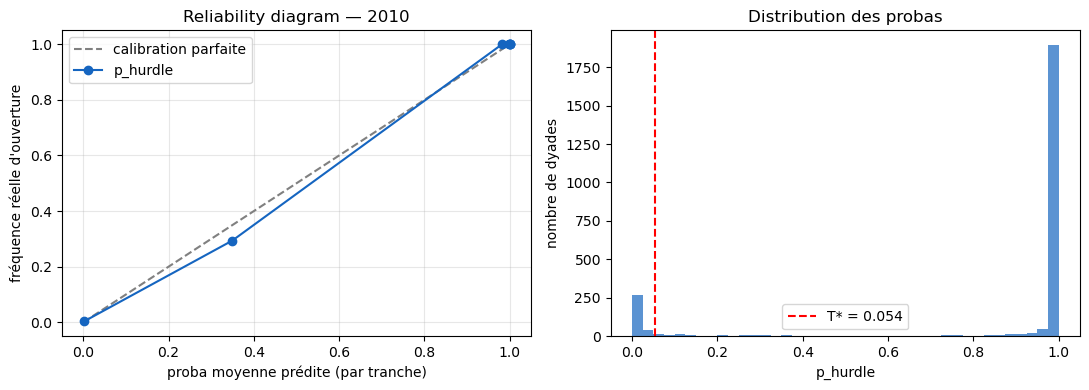

In [296]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# p_c, y_c = probas hurdle et cible sur l'année de calibration (déjà définis au-dessus)
frac_pos, mean_pred = calibration_curve(y_c, p_c, n_bins=10, strategy='quantile')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# gauche : reliability diagram 
ax1.plot([0, 1], [0, 1], '--', color='grey', label='calibration parfaite')
ax1.plot(mean_pred, frac_pos, 'o-', color='#1565C0', label='p_hurdle')
ax1.set_xlabel("proba moyenne prédite (par tranche)")
ax1.set_ylabel("fréquence réelle d'ouverture")
ax1.set_title(f"Reliability diagram — {CALIB_YEAR}")
ax1.legend(); ax1.grid(alpha=0.3)

# droite : histogramme des probas (voir si tout est tassé) 
ax2.hist(p_c, bins=40, color='#1565C0', alpha=0.7)
ax2.axvline(T_FINAL, color='red', ls='--', label=f'T* = {T_FINAL:.3f}')
ax2.set_xlabel("p_hurdle"); ax2.set_ylabel("nombre de dyades")
ax2.set_title("Distribution des probas"); ax2.legend()
plt.tight_layout(); plt.show()

In [297]:
#  PRODUCTION FINALE 

# remplace la calibration ROC data leakage (sur 2015) par les seuils calibrés sur 2010 par 5-fold CV


#  proba d'ouverture = hurdle Stan posterior (plus proba_rf) 
p_hurdle_test = df_test['p_hurdle'].values           # rempli par la cellule d'extraction
assert not np.isnan(p_hurdle_test).any(), "p_hurdle_test contient des NaN"

#  seuillage is_mig_lag, seuils calibrés sur 2010 
# 'seuils' = dict {1: t_existants, 0: t_emergents}
thr_vec    = np.where(df_test['is_mig_lag'].values == 1, seuils[1], seuils[0])
y_pred_bin = (p_hurdle_test >= thr_vec).astype(int)
y_pred     = np.where(y_pred_bin == 1, flow_cond_med_final, 0.0)

#  intervalles : propage l'incertitude d'ouverture ET de volume 

#prob_clean = np.tile(p_hurdle_test, (mu_clean.shape[0], 1))
prob_draws = df_final.filter(like='prob_mig_test').values[valid_draws]
is_mig_sim = np.random.binomial(1, np.clip(prob_draws, 0, 1))
flow_all   = is_mig_sim * flow_cond_sim
y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0)
y_pred_q95 = np.percentile(flow_all, 97.5, axis=0)

y_true     = df_test['flow'].values                     
y_true_bin = (y_true > 0).astype(int)

print(f"Ouvertures prédites : {y_pred_bin.sum():,} / {len(y_pred_bin):,} "
      f"(réel : {y_true_bin.sum():,})")

Ouvertures prédites : 2,091 / 2,450 (réel : 2,035)


In [298]:
# ancienne cellule seuils régionalisé 






# # y_true     = df_test['flow'].values
# y_true_bin = (y_true > 0).astype(int)

# W_FP_global  = 25.0
# cluster_test = df_test['continent_orig_fill'].values

# fpr_ref, tpr_ref, thresh_ref = roc_curve(y_true_bin, prob_med)
# score_ref         = tpr_ref - (W_FP_global * fpr_ref)
# optimal_threshold = thresh_ref[np.argmax(score_ref)]

# seuil_par_cluster = {}
# wp_par_cluster    = {}

# for cluster_id in np.unique(cluster_test):
#     mask_c = (cluster_test == cluster_id)
#     n_pos  = y_true_bin[mask_c].sum()
#     n_neg  = (1 - y_true_bin[mask_c]).sum()
#     if n_pos < 30 or n_neg < 30:
#         fpr_g, tpr_g, thresh_g = roc_curve(y_true_bin, prob_med)
#         seuil_par_cluster[cluster_id] = thresh_g[np.argmax(tpr_g - W_FP_global * fpr_g)]
#         wp_par_cluster[cluster_id]    = W_FP_global
#         continue
#     ratio        = n_neg / n_pos
#     ratio_global = (1 - y_true_bin).sum() / y_true_bin.sum()
#     wp_c         = np.clip(W_FP_global * (ratio / ratio_global), 2.0, 50.0)
#     wp_par_cluster[cluster_id] = wp_c
#     fpr_c, tpr_c, thresh_c = roc_curve(y_true_bin[mask_c], prob_med[mask_c])
#     seuil_par_cluster[cluster_id] = thresh_c[np.argmax(tpr_c - wp_c * fpr_c)]
#     label = SUBREGION_LABELS.get(stan_to_m49.get(cluster_id, 99), f'cluster_{cluster_id}')
#     print(f"  {label:<30} seuil={seuil_par_cluster[cluster_id]:.3f}  WP={wp_c:.1f}  n_pos={n_pos}  n_neg={n_neg}")

# y_pred_bin_cluster = np.zeros(len(y_true_bin), dtype=int)
# for cluster_id, seuil_c in seuil_par_cluster.items():
#     mask_c = (cluster_test == cluster_id)
#     y_pred_bin_cluster[mask_c] = (prob_med[mask_c] > seuil_c).astype(int)

# y_pred     = np.where(y_pred_bin_cluster == 1, flow_cond_med_final, 0.0)
# y_pred_bin = y_pred_bin_cluster

# # Intervalles de confiance : prob XGB broadcast sur les draws volume
# prob_clean = np.tile(prob_med, (mu_clean.shape[0], 1))
# is_mig_sim = np.random.binomial(1, np.clip(prob_clean, 0, 1))
# flow_all   = is_mig_sim * flow_cond_sim
# y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0)
# y_pred_q95 = np.percentile(flow_all, 97.5, axis=0)

# print(f"\nSeuil global de référence : {optimal_threshold:.3f}")

In [299]:
acc        = accuracy_score(y_true_bin, y_pred_bin)
global_mae = np.mean(np.abs(y_true - y_pred))
mape_wr    = np.mean(np.abs(y_true - y_pred) / (y_true + 1.0)) * 100
wmape      = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100
log_mae    = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage   = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))

print(f"Accuracy Hurdle   : {acc*100:.1f}%")
print(f"MAE               : {global_mae:,.0f}")
print(f"MAPE (W&R)        : {mape_wr:.1f}%")
print(f"WMAPE             : {wmape:.1f}%")
print(f"Log-MAE           : {log_mae:.4f}")
print(f"Coverage 95%      : {coverage*100:.1f}%")
print()
print(f"{'Modèle':<40} | {'MAE':>10} | {'MAPE':>10} | {'Coverage':>10}")
print("-" * 78)
print(f"{'Welch & Raftery (2022)':<40} | {'~1,200':>10} | {'76.0%':>10} | {'93.0%':>10}")
print(f"{f'Hurdle ARX ZTNB ({N_pays} pays)':<40} | {global_mae:>10,.0f} | {f'{mape_wr:.1f}%':>10} | {f'{coverage*100:.1f}%':>10}")

Accuracy Hurdle   : 96.1%
MAE               : 7,902
MAPE (W&R)        : 316.4%
WMAPE             : 41.6%
Log-MAE           : 0.6406
Coverage 95%      : 96.2%

Modèle                                   |        MAE |       MAPE |   Coverage
------------------------------------------------------------------------------
Welch & Raftery (2022)                   |     ~1,200 |      76.0% |      93.0%
Hurdle ARX ZTNB (50 pays)                |      7,902 |     316.4% |      96.2%


In [300]:
# Tableau de diagnostic bayésien

CLUSTER_LABELS = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}')
                  for k in range(1, K_clusters + 1)]
Z_LABELS = [f'Z_{k}' for k in range(1, K_Z + 1)]

SCALAIRES = [
    # Volume
    'rho_global_monitor', 'sigma_rho_m49','tau_rho', 'tau_em', 'tau_at', 
    'intercept_em', 'intercept_at', 'phi_disp_global', 'tau_phi_disp',
    # Hurdle
    'mu_beta_lag', 'sigma_beta_lag',
    'intercept_h_em', 'intercept_h_at', 'tau_h_em', 'tau_h_at',
    'tau_u_em',   # échelle du champ spatial : ~0 => l'ICAR ne sert à rien (piste 3)
]

VECTORIELS = {
    'beta_grav'        : X_VOL_COLS,
    'beta_h'           : HURDLE_VARS,      # 12 entrées après le retrait de is_mig_lag
    'beta_lag_m49'     : CLUSTER_LABELS,
    'theta_em'         : Z_LABELS,
    'theta_at'         : Z_LABELS,
    'theta_h_em'       : Z_LABELS,
    'theta_h_at'       : Z_LABELS,
    'phi_disp_cluster' : CLUSTER_LABELS,
    'rho_m49'          : CLUSTER_LABELS,   # moyenne intra-cluster des rho_d (GQ)
}

def ess_bulk(draws):
    from scipy.stats import rankdata
    n = len(draws)
    if n < 4:
        return np.nan
    r = rankdata(draws) / (n + 1)
    z = np.where(r < 0.5, -np.sqrt(2)*np.log(1/(2*r)), np.sqrt(2)*np.log(1/(2*(1-r))))
    if z.var() < 1e-10:
        return n
    ac1 = np.corrcoef(z[:-1], z[1:])[0, 1]
    rho = max(ac1, 0)
    return round(n * (1 - rho) / (1 + rho))

def rhat(chains_draws):
    m = len(chains_draws)
    n = min(len(c) for c in chains_draws)
    chains = np.array([c[:n] for c in chains_draws])
    B = n * np.var(chains.mean(axis=1), ddof=1)
    W = np.mean([np.var(chains[i], ddof=1) for i in range(m)])
    return round(np.sqrt(((n-1)/n * W + B/n) / W), 4) if W > 0 else np.nan

def summarize_param(name, draws_all, chains_draws):
    q = np.percentile(draws_all, [5, 25, 50, 75, 95])
    sig = '*' if (q[0] > 0 or q[4] < 0) else ''
    return {'Paramètre': name, 'Médiane': round(q[2], 4),
            'IC 5%': round(q[0], 4), 'IC 95%': round(q[4], 4),
            'ESS': ess_bulk(draws_all), 'R-hat': rhat(chains_draws), 'Sig': sig}

# découpage par chaîne sur la longueur RÉELLE (df_final = concat des chaînes, dans l'ordre)
n_per_chain = len(df_final) // N_CHAINS
assert n_per_chain * N_CHAINS == len(df_final), "df_final n'est pas un multiple de N_CHAINS"

def _chains(col):
    v = df_final[col].values.astype(float)
    return [v[i*n_per_chain:(i+1)*n_per_chain] for i in range(N_CHAINS)]

rows, manquants = [], []

for param in SCALAIRES:
    if param not in df_final.columns:
        manquants.append(param); continue
    rows.append(summarize_param(param, df_final[param].values.astype(float), _chains(param)))

for param, labels in VECTORIELS.items():
    cols = [c for c in df_final.columns if c.startswith(f'{param}.')]   # notation POINTÉE
    cols = sorted(cols, key=lambda x: int(x.split('.')[1]))
    if not cols:
        manquants.append(param); continue
    if len(cols) != len(labels):
        print(f"[warn] {param} : {len(cols)} colonnes vs {len(labels)} labels")
    for j, col in enumerate(cols):
        label = labels[j] if j < len(labels) else f'{j+1}'
        rows.append(summarize_param(f'{param}[{label}]',
                                    df_final[col].values.astype(float), _chains(col)))

if manquants:
    print(f"[warn] absents de df_final — vérifier vars_to_keep : {manquants}\n")

summary_df = pd.DataFrame(rows)

print(f"{'Paramètre':<35} {'Médiane':>9} {'IC 5%':>9} {'IC 95%':>9} {'ESS':>6} {'R-hat':>7} {'Sig':>4}")
print("-" * 85)
for _, r in summary_df.iterrows():
    flag = ' !' if (r['R-hat'] > 1.01 or r['ESS'] < 400) else ''
    print(f"{r['Paramètre']:<35} {r['Médiane']:>9.4f} {r['IC 5%']:>9.4f} {r['IC 95%']:>9.4f} "
          f"{int(r['ESS']) if not np.isnan(r['ESS']) else 'NaN':>6} {r['R-hat']:>7.4f} {r['Sig']:>4}{flag}")

n_div = int(df_final.get('divergent__', pd.Series([0])).sum())
print(f"\nDivergences : {n_div}")
if 'treedepth__' in df_final.columns:
    print(f"Treedepth saturé (>={MAX_TREEDEPTH}) : {(df_final['treedepth__'] >= MAX_TREEDEPTH).mean()*100:.1f}%")
bad = summary_df[(summary_df['R-hat'] > 1.01) | (summary_df['ESS'] < 400)]
print(f"Paramètres hors seuils : {len(bad)}")

Paramètre                             Médiane     IC 5%    IC 95%    ESS   R-hat  Sig
-------------------------------------------------------------------------------------
rho_global_monitor                     0.8568    0.7971    0.8990    347  1.0090    * !
sigma_rho_m49                          0.4326    0.3053    0.6382    787  1.0034    *
tau_rho                                0.3876    0.3525    0.4217    964  0.9993    *
tau_em                                 0.8572    0.7350    1.0230    752  1.0021    *
tau_at                                 0.9372    0.8233    1.0840    551  1.0012    *
intercept_em                           4.0785    2.9412    5.3114   1507  1.0004    *
intercept_at                           4.1410    2.8718    5.2964   1528  1.0001    *
phi_disp_global                        1.1645    0.9454    1.4230   1600  0.9998    *
tau_phi_disp                           1.1600    1.1070    1.2170    859  1.0008    *
mu_beta_lag                           -4.0640   -4.5


[ HURDLE (Logit) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
log_D_ij                       0.511     -0.082      1.129   non
log_D_ij_sq                   -0.134     -0.729      0.435   non
COL_ij                         0.141     -2.919      3.298   non
OL_ij                          0.345     -0.077      0.772   non
v2x_polyarchy_o_lag1          -0.204     -0.413     -0.011   OUI
v2x_polyarchy_d_lag1          -0.277     -0.452     -0.097   OUI
A2_log                         0.793      0.644      0.948   OUI
logit_rf                      11.353     10.710     12.040   OUI

[ VOLUME (ZTNB) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
log_D_ij                      -0.576     -1.102     -0.063   OUI
log_D_ij_sq                   -0.484     -0.980      0.030   non
LB_ij                          2.323      2.037  

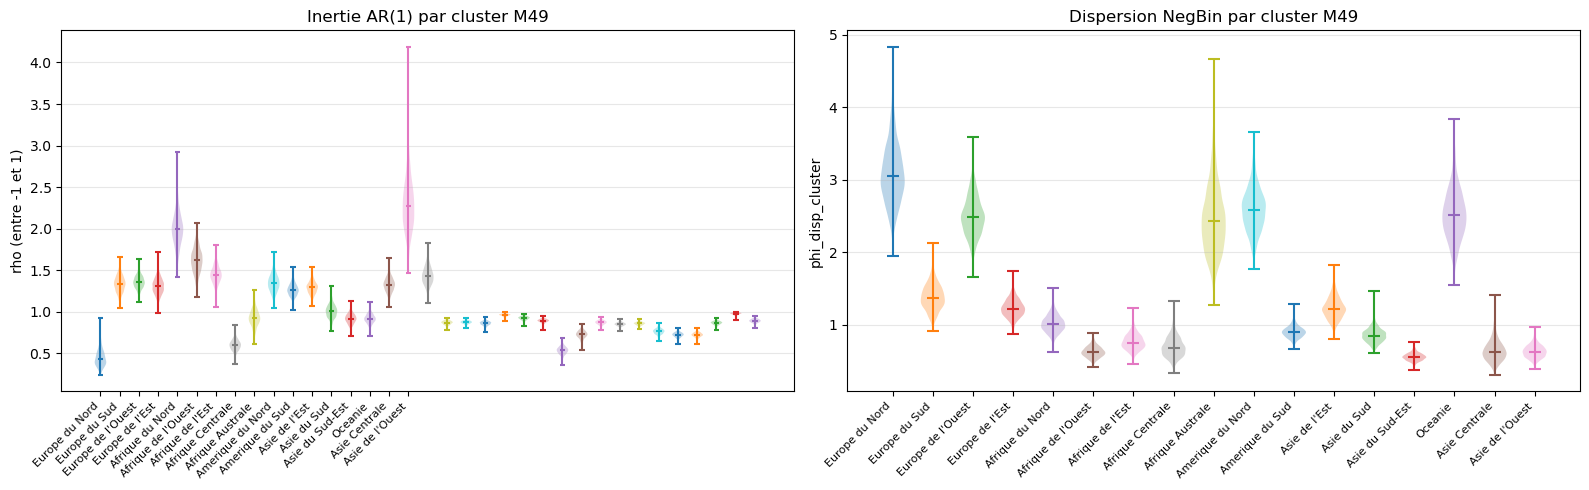

In [301]:
# Tableau des coefficients Hurdle et Volume
def print_coef_table(name, means, q05, q95, labels):
    print(f"\n[ {name} ]")
    print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10} {'Sig':>5}")
    print("-" * 65)
    for j in range(len(means)):
        col = labels[j] if j < len(labels) else f'[{j+1}]'
        sig = 'OUI' if (q05[j] > 0 or q95[j] < 0) else 'non'
        print(f"{col:<25} {means[j]:>10.3f} {q05[j]:>10.3f} {q95[j]:>10.3f} {sig:>5}")

# Tableau Hurdle
print_coef_table(
    'HURDLE (Logit)',
    beta_h.mean(axis=0),
    np.percentile(beta_h, 5, axis=0),   # Modifiable à 2.5 si nécessaire pour matcher le IC 95% du graphe
    np.percentile(beta_h, 95, axis=0),  # Modifiable à 97.5
    HURDLE_VARS
)

print_coef_table(
    'VOLUME (ZTNB)',
    beta_grav.mean(axis=0),
    np.percentile(beta_grav, 5, axis=0),
    np.percentile(beta_grav, 95, axis=0),
    X_VOL_COLS
)
rho_m49_draws       = df_final.filter(like='rho_m49').values
phi_cluster_draws   = df_final.filter(like='phi_disp_cluster').values
cluster_labels      = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}')
                       for k in range(1, K_clusters + 1)]

print_coef_table(
    'RHO AR(1) par cluster M49',
    rho_m49_draws.mean(axis=0),
    np.percentile(rho_m49_draws,  5, axis=0),
    np.percentile(rho_m49_draws, 95, axis=0),
    cluster_labels
)

print_coef_table(
    'PHI dispersion par cluster M49',
    phi_cluster_draws.mean(axis=0),
    np.percentile(phi_cluster_draws,  5, axis=0),
    np.percentile(phi_cluster_draws, 95, axis=0),
    cluster_labels
)

# Figure comparative rho vs phi par cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, draws, title, ylabel in [
    (axes[0], rho_m49_draws,     'Inertie AR(1) par cluster M49',       'rho (entre -1 et 1)'),
    (axes[1], phi_cluster_draws, 'Dispersion NegBin par cluster M49',   'phi_disp_cluster'),
]:
    for k in range(draws.shape[1]):
        ax.violinplot(draws[:, k], positions=[k + 1], widths=0.6, showmedians=True)
    ax.set_xticks(range(1, K_clusters + 1))
    ax.set_xticklabels(cluster_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"rho_phi_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

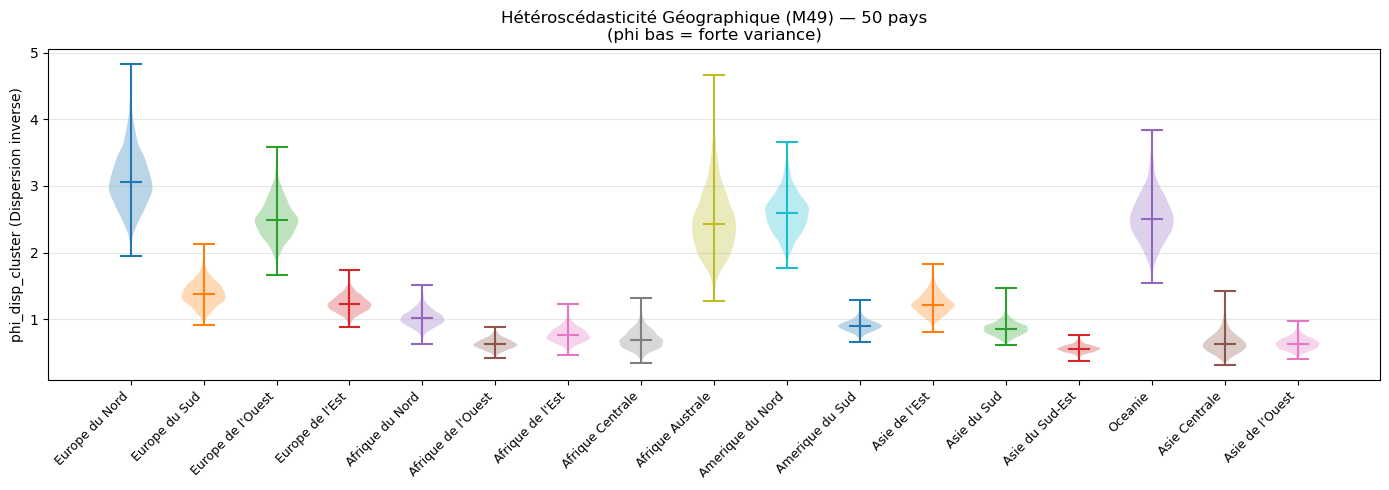

In [302]:
# Figure : hétéroscédasticité M49
fig, ax = plt.subplots(figsize=(14, 5))
for k in range(1, K_clusters + 1):
    draws_k = phi_disp_cluster[:, k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels(
    [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'Cluster {k}') for k in range(1, K_clusters + 1)],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel("phi_disp_cluster (Dispersion inverse)")
ax.set_title(f"Hétéroscédasticité Géographique (M49) — {N_pays} pays\n(phi bas = forte variance)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"NegBin_dispersion_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

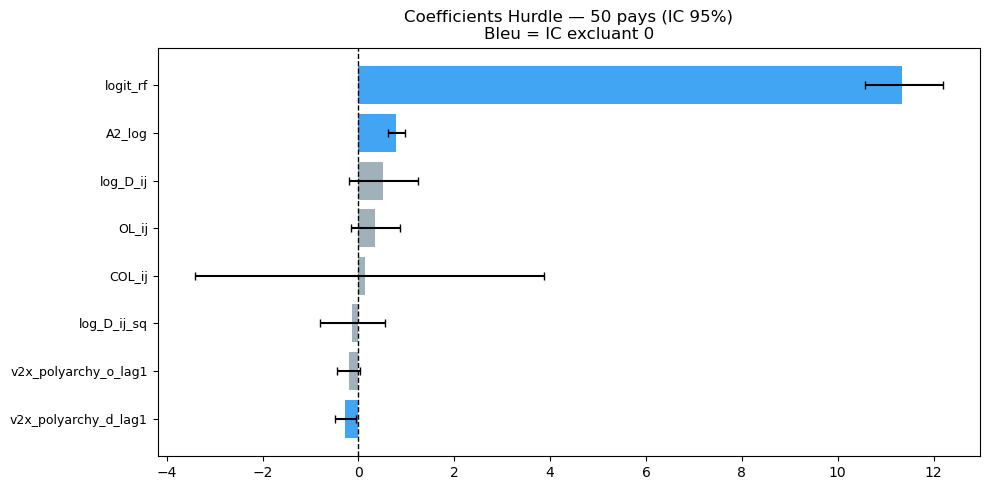

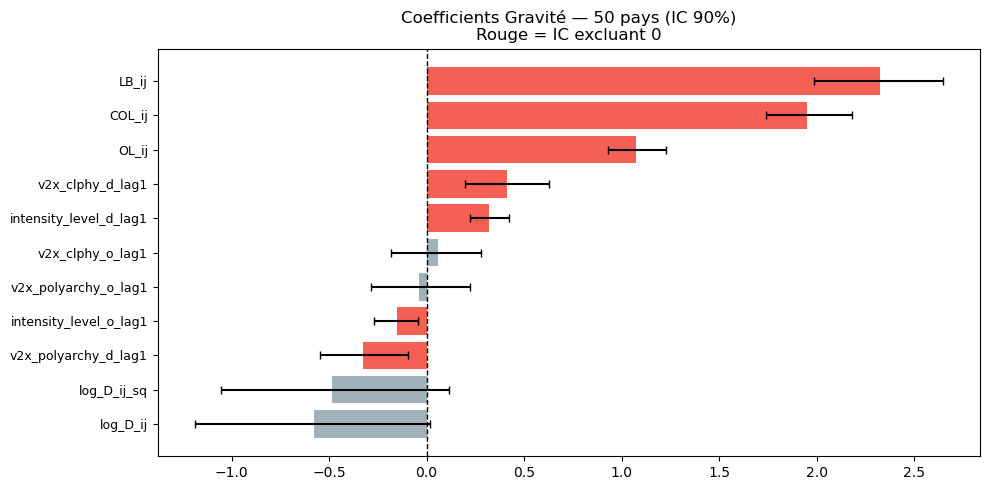

In [303]:
# Figure : coefficients Hurdle et Volume
def plot_coefs(means, q05, q95, labels, title, color_sig, fname):
    K = len(means)
    order = np.argsort(means)
    colors = [color_sig if (q05[i] > 0 or q95[i] < 0) else '#90A4AE' for i in order]
    fig, ax = plt.subplots(figsize=(10, max(5, K * 0.45)))
    ax.barh(
        range(K), means[order],
        xerr=[means[order] - q05[order], q95[order] - means[order]],
        color=colors, alpha=0.85, capsize=3
    )
    ax.set_yticks(range(K))
    ax.set_yticklabels([labels[i] for i in order], fontsize=9)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

# Figure : Coefficients Hurdle
plot_coefs(
    beta_h.mean(axis=0), 
    np.percentile(beta_h, 2.5, axis=0), 
    np.percentile(beta_h, 97.5, axis=0),
    HURDLE_VARS,
    f"Coefficients Hurdle — {N_pays} pays (IC 95%)\nBleu = IC excluant 0",
    '#2196F3', 
    f"NegBin_hurdle_coefficients_{N_pays}.pdf"
)

plot_coefs(
    beta_grav.mean(axis=0), np.percentile(beta_grav, 2.5, axis=0), np.percentile(beta_grav, 97.5, axis=0),
    X_VOL_COLS,
    f"Coefficients Gravité — {N_pays} pays (IC 90%)\nRouge = IC excluant 0",
    '#F44336', f"NegBin_gravity_coefficients_{N_pays}.pdf"
)

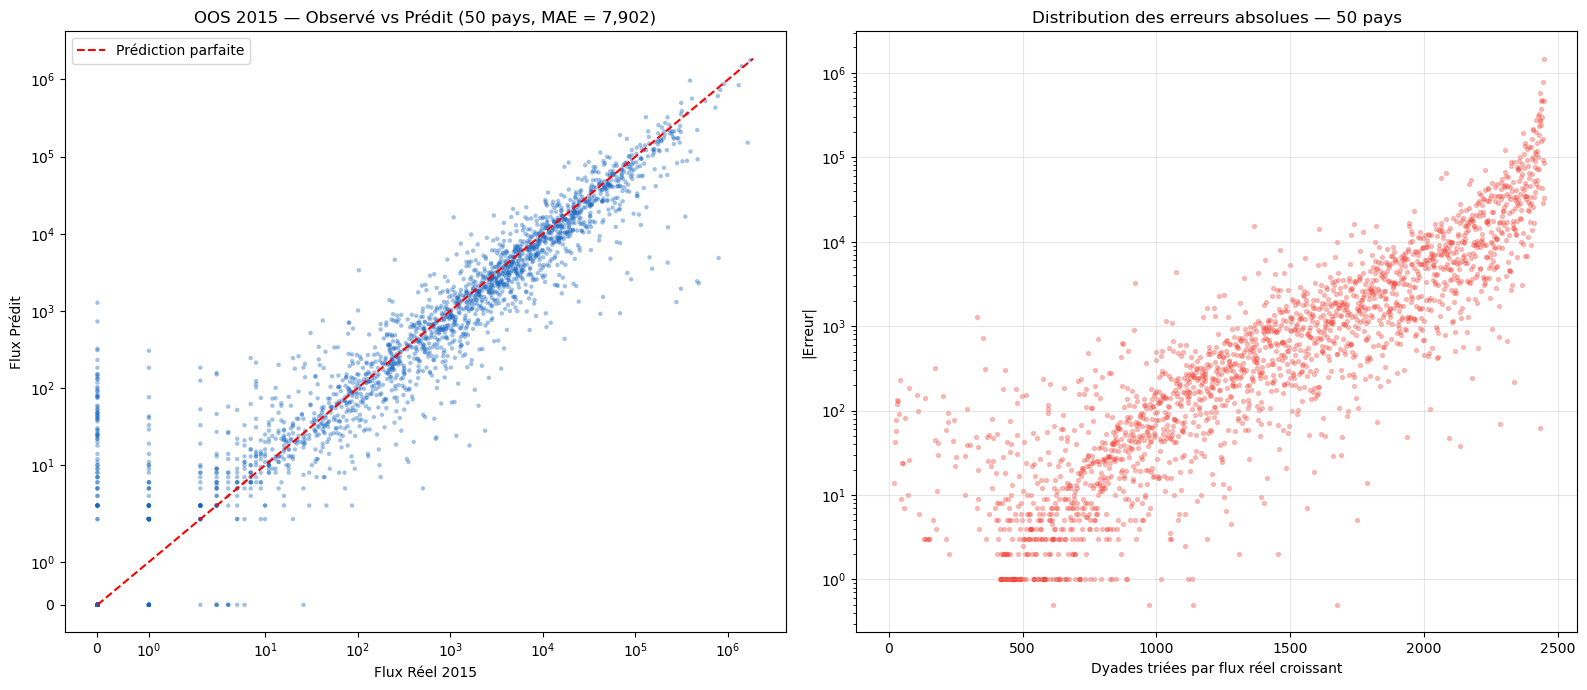

In [304]:
# Figure : scatter OOS + distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=10, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit ({N_pays} pays, MAE = {global_mae:,.0f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title(f"Distribution des erreurs absolues — {N_pays} pays")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"NegBin_prediction_scatter_{N_pays}.pdf", bbox_inches='tight')
plt.show()

In [305]:
# Cartographie FP / FN
import plotly.express as px

df_test['y_true_bin'] = y_true_bin
df_test['y_pred_bin'] = y_pred_bin
df_test['FN'] = ((df_test['y_true_bin'] == 1) & (df_test['y_pred_bin'] == 0)).astype(int)
df_test['FP'] = ((df_test['y_true_bin'] == 0) & (df_test['y_pred_bin'] == 1)).astype(int)

error_map = df_test.groupby('orig')[['FN', 'FP']].sum().reset_index()
print(f"FN : {df_test['FN'].sum()} | FP : {df_test['FP'].sum()}")

for col, scale, title in [
    ('FN', 'Reds',  'Cartographie Faux Négatifs (FN) par pays d\'origine'),
    ('FP', 'Blues', 'Cartographie Faux Positifs (FP) par pays d\'origine'),
]:
    fig = px.choropleth(
        error_map, locations='orig', color=col,
        hover_name='orig', color_continuous_scale=scale,
        title=title, labels={col: f'Nombre de {col}'}
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
    fig.show()

FN : 20 | FP : 76
